<a href="https://colab.research.google.com/github/dougyd92/ML-Foudations/blob/main/Notebooks/14_Training_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 14: Training Neural Networks — Companion Notebook

In Session 13, you learned what a neural network is and how forward propagation produces predictions. This notebook covers **how neural networks learn**: backpropagation, loss functions, optimizers, and the training loop.

By the end of this notebook, you will have:
1. Seen PyTorch's autograd compute backpropagation for you
2. Compared SGD, SGD with momentum, and Adam on the same problem
3. Trained a neural network regressor on the California Housing dataset
4. Trained a neural network classifier on the Breast Cancer Wisconsin dataset


---

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Check if GPU is available (Colab sometimes provides one)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('All imports successful!')

Using device: cpu
All imports successful!


---
# Section 1: Autograd — Backpropagation in PyTorch

In the slides, we traced backpropagation by hand: start at the loss, apply the chain rule layer by layer, compute a gradient for every weight. PyTorch does all of this automatically with **autograd**.

The key idea: when you set `requires_grad=True` on a tensor, PyTorch records every operation you perform on it in a computational graph. When you call `.backward()`, it walks that graph in reverse and computes all the gradients.

### Tensors with gradient tracking

In [3]:
# A regular tensor: just a number
x = torch.tensor(3.0)
print(f'x = {x}, requires_grad = {x.requires_grad}')

# A tensor that tracks gradients
w = torch.tensor(2.0, requires_grad=True)
print(f'w = {w}, requires_grad = {w.requires_grad}')

x = 3.0, requires_grad = False
w = 2.0, requires_grad = True


### A simple computational graph

Let's compute $y = w \cdot x + b$, then a loss $L = (y - t)^2$ where $t$ is the target. This is one neuron with no activation, trained on one sample with MSE loss.

In [4]:
# One 'neuron': y = w * x + b
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
x = torch.tensor(3.0)   # input (no gradient needed)
t = torch.tensor(7.0)   # target

# Forward pass
y = w * x + b
y
# prediction: 2*3 + 0.5 = 6.5

tensor(6.5000, grad_fn=<AddBackward0>)

In [5]:
loss = (y - t) ** 2      # MSE on one sample: (6.5 - 7)^2 = 0.25

print(f'Prediction: y = {y.item():.1f}')
print(f'Target:     t = {t.item():.1f}')
print(f'Loss:       L = {loss.item():.4f}')

Prediction: y = 6.5
Target:     t = 7.0
Loss:       L = 0.2500


### Backward pass: one line

Calling `loss.backward()` computes $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$ automatically. These are stored in `.grad`.

In [6]:
# Backward pass: compute all gradients
loss.backward()

print(f'dL/dw = {w.grad.item():.4f}')
print(f'dL/db = {b.grad.item():.4f}')

dL/dw = -3.0000
dL/db = -1.0000


### Verifying by hand

Let's check those gradients manually using the chain rule:

$$L = (y - t)^2, \quad y = wx + b$$

$$\frac{\partial L}{\partial y} = 2(y - t) = 2(6.5 - 7) = -1.0$$

$$\frac{\partial y}{\partial w} = x = 3.0, \quad \frac{\partial y}{\partial b} = 1$$

$$\frac{\partial L}{\partial w} = -1.0 \times 3.0 = -3.0, \quad \frac{\partial L}{\partial b} = -1.0 \times 1.0 = -1.0$$

In [8]:
# Verify: our manual calculation matches autograd
dL_dy = 2 * (y.item() - t.item())
dy_dw = x.item()
dy_db = 1.0

print(f'Manual dL/dw = {dL_dy * dy_dw:.4f}  |  Autograd: {w.grad.item():.4f}')
print(f'Manual dL/db = {dL_dy * dy_db:.4f}  |  Autograd: {b.grad.item():.4f}')

Manual dL/dw = -3.0000  |  Autograd: -3.0000
Manual dL/db = -1.0000  |  Autograd: -1.0000


### Autograd through a hidden layer

Now let's verify autograd on a network with a hidden layer — the same architecture from the Session 13 forward pass worked example. This is what `loss.backward()` computes for a real network.

In [9]:
# Session 13 network: 2 inputs, 2 hidden (ReLU), 1 output (sigmoid)
# Same weights from the Session 13/14 worked example
x1, x2 = torch.tensor(1.0), torch.tensor(0.0)
y_true = torch.tensor(1.0)

# Hidden layer weights (requires_grad for all weights)
w11 = torch.tensor(0.5, requires_grad=True)
w12 = torch.tensor(-0.3, requires_grad=True)
b1  = torch.tensor(0.1, requires_grad=True)
w21 = torch.tensor(-0.4, requires_grad=True)
w22 = torch.tensor(0.8, requires_grad=True)
b2  = torch.tensor(0.2, requires_grad=True)

# Output layer weights
w_o1 = torch.tensor(0.6, requires_grad=True)
w_o2 = torch.tensor(-0.5, requires_grad=True)
b_o  = torch.tensor(0.1, requires_grad=True)

# Forward pass (same as Session 13)
z1 = w11 * x1 + w12 * x2 + b1
a1 = torch.relu(z1)
z2 = w21 * x1 + w22 * x2 + b2
a2 = torch.relu(z2)
z_out = w_o1 * a1 + w_o2 * a2 + b_o
y_hat = torch.sigmoid(z_out)

# Binary cross-entropy loss
loss = -(y_true * torch.log(y_hat) + (1 - y_true) * torch.log(1 - y_hat))

print(f'Forward pass:')
print(f'  z1 = {z1.item():.3f}, a1 = {a1.item():.3f}')
print(f'  z2 = {z2.item():.3f}, a2 = {a2.item():.3f}')
print(f'  z_out = {z_out.item():.3f}, y_hat = {y_hat.item():.3f}')
print(f'  Loss = {loss.item():.3f}')

Forward pass:
  z1 = 0.600, a1 = 0.600
  z2 = -0.200, a2 = 0.000
  z_out = 0.460, y_hat = 0.613
  Loss = 0.489


In [10]:
# Backward pass: one line computes ALL gradients
loss.backward()

print(f'Gradients (autograd):')
print(f'  Output layer:')
print(f'    dL/dw_o1 = {w_o1.grad.item():.3f}')
print(f'    dL/dw_o2 = {w_o2.grad.item():.3f}')
print(f'    dL/db_o  = {b_o.grad.item():.3f}')
print(f'  Hidden layer:')
print(f'    dL/dw11  = {w11.grad.item():.3f}')
print(f'    dL/dw12  = {w12.grad.item():.3f}')
print(f'    dL/db1   = {b1.grad.item():.3f}')
print(f'    dL/dw21  = {w21.grad.item():.3f}  (dead neuron: ReLU killed z2)')
print(f'    dL/dw22  = {w22.grad.item():.3f}  (dead neuron: ReLU killed z2)')
print(f'    dL/db2   = {b2.grad.item():.3f}  (dead neuron: ReLU killed z2)')

Gradients (autograd):
  Output layer:
    dL/dw_o1 = -0.232
    dL/dw_o2 = -0.000
    dL/db_o  = -0.387
  Hidden layer:
    dL/dw11  = -0.232
    dL/dw12  = -0.000
    dL/db1   = -0.232
    dL/dw21  = 0.000  (dead neuron: ReLU killed z2)
    dL/dw22  = 0.000  (dead neuron: ReLU killed z2)
    dL/db2   = 0.000  (dead neuron: ReLU killed z2)


Notice: the gradients for hidden neuron 2 are all zero because $z_2 = -0.2 < 0$, so ReLU output was 0 and the gradient can't flow through. This is the "dead neuron" we identified in the slides.

---
## Exercise 1: Gradient Computation and Verification



### Task 1: Compute gradients for a two-layer computation

Given $z = 3w^2 + 2w - 1$ and $L = (z - 10)^2$:
1. Compute $\frac{\partial L}{\partial w}$ by hand at $w = 2$
2. Verify your answer using PyTorch autograd

In [37]:
# Hint:
# z = 3w^2 + 2w - 1. At w=2: z = 3(4) + 2(2) - 1 = 15
# L = (z - 10)^2 = (15 - 10)^2 = 25
# dL/dz = 2(z - 10) = 10
# dz/dw = 6w + 2 = 14
# dL/dw = dL/dz * dz/dw = ?

# Verify with autograd:
# w = torch.tensor(2.0, requires_grad=True)
# z = ...
# L = ...
# L.backward()
# print(w.grad)

# Your code here

In [ ]:
#@title Click to reveal solution

# Manual calculation:
# dL/dw = dL/dz * dz/dw = 10 * 14 = 140

# Autograd verification
w = torch.tensor(2.0, requires_grad=True)
z = 3 * w**2 + 2 * w - 1
L = (z - 10) ** 2
L.backward()

print(f'Manual dL/dw = 140.0')
print(f'Autograd dL/dw = {w.grad.item():.1f}')

### Task 2: What happens when you call backward twice?

Try calling `loss.backward()` a second time on the same computation. What error do you get, and why?

Then try creating the computation with `retain_graph=True` and calling backward twice. What happens to the `.grad` value?

In [17]:
# Part A: try calling backward twice (you should get an error)
# Part B: use retain_graph=True and observe what happens to grad

# Your code here

tensor(140.)
tensor(280.)
tensor(420.)


In [ ]:
#@title Click to reveal solution

# Part A: backward twice without retain_graph
w = torch.tensor(2.0, requires_grad=True)
z = 3 * w**2 + 2 * w - 1
L = (z - 10) ** 2
L.backward()
print(f'First backward: grad = {w.grad.item():.1f}')

try:
    L.backward()
except RuntimeError as e:
    print(f'Error on second backward: {e}')
print('The graph is freed after backward() to save memory.')

# Part B: retain_graph=True
print()
w = torch.tensor(2.0, requires_grad=True)
z = 3 * w**2 + 2 * w - 1
L = (z - 10) ** 2
L.backward(retain_graph=True)
print(f'First backward: grad = {w.grad.item():.1f}')
L.backward()
print(f'Second backward (accumulates!): grad = {w.grad.item():.1f}')
print('Gradients ACCUMULATE by default. This is why we call zero_grad() in the training loop!')

---
# Section 2: Loss Functions in PyTorch

You already know MSE and cross-entropy. Here we see how PyTorch implements them and verify they match what you expect.

In [18]:
# MSE Loss: regression
predictions = torch.tensor([2.5, 3.0, 4.5])
targets = torch.tensor([3.0, 3.0, 5.0])

# Manual MSE
mse_manual = ((predictions - targets) ** 2).mean()
print(f'Manual MSE:  {mse_manual.item():.4f}')


Manual MSE:  0.1667


In [19]:
# PyTorch MSE
criterion = nn.MSELoss()
mse_pytorch = criterion(predictions, targets)
print(f'PyTorch MSE: {mse_pytorch.item():.4f}')

PyTorch MSE: 0.1667


In [22]:
# Cross-Entropy Loss: classification
# PyTorch's CrossEntropyLoss expects raw logits (before softmax), not probabilities
# It applies softmax internally, then computes -log(p_correct)

# 4 samples, 3 classes. Raw logits (not probabilities!)
logits = torch.tensor([[2.0, 0.5, 0.1],     # model is most confident about class 0
                        [0.1, 2.5, 0.3],    # model is most confident about class 1
                        [0.3, 0.2, 3.0],    # model is most confident about class 2
                        [0.3, 3.1, 0.1]])   # model is most confident about class 1
true_labels = torch.tensor([0, 1, 2, 1])        # all predictions happen to be correct

criterion = nn.CrossEntropyLoss()
loss = criterion(logits, true_labels)
print(f'Cross-entropy loss: {loss.item():.4f}')
print(f'(Low loss because the model\'s confident predictions match the true labels)')


Cross-entropy loss: 0.1814
(Low loss because the model's confident predictions match the true labels)


In [21]:
# What if the model is wrong?
true_labels_wrong = torch.tensor([2, 0, 1, 0])  # all wrong
loss_wrong = criterion(logits, true_labels_wrong)
print(f'Cross-entropy loss (wrong predictions): {loss_wrong.item():.4f}')
print(f'(Higher loss because confident predictions are incorrect)')

Cross-entropy loss (wrong predictions): 2.7992
(Higher loss because confident predictions are incorrect)


**Key detail:** `nn.CrossEntropyLoss` expects **raw logits**, not probabilities. It applies softmax internally. This is a common source of bugs — don't apply softmax to your output layer and then pass the result to `CrossEntropyLoss`.

---
# Section 3: Optimizers in Action

Let's compare SGD, SGD with momentum, and Adam on the same optimization problem. We'll minimize a simple 2D loss function and watch how each optimizer navigates the landscape.

In [54]:
# Define a loss surface: L = 0.5 * (a * w1^2 + b * w2^2)
# Narrow valley: steep in w2, shallow in w1
a_coeff, b_coeff = 0.5, 10.0

def loss_fn(w):
    return 0.5 * (a_coeff * w[0]**2 + b_coeff * w[1]**2)

def run_optimizer(opt_class, opt_kwargs, start, n_steps=50):
    w = torch.tensor(start, requires_grad=True)
    path = [start.copy()]
    optimizer = opt_class([w], **opt_kwargs)
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = loss_fn(w)
        loss.backward()
        optimizer.step()
        path.append([w[0].item(), w[1].item()])
    return path

# Same starting point for all three
start = [3.0, 2.0]
sgd_path = run_optimizer(optim.SGD, {'lr': 0.18}, start)
mom_path = run_optimizer(optim.SGD, {'lr': 0.18, 'momentum': 0.6}, start)
adam_path = run_optimizer(optim.Adam, {'lr': 0.18}, start)
# ^ Try setting different learning rate values for each and see what happens!

print(f'SGD final:      ({sgd_path[-1][0]:.4f}, {sgd_path[-1][1]:.4f})')
print(f'Momentum final: ({mom_path[-1][0]:.4f}, {mom_path[-1][1]:.4f})')
print(f'Adam final:     ({adam_path[-1][0]:.4f}, {adam_path[-1][1]:.4f})')

SGD final:      (0.0269, 0.0000)
Momentum final: (-0.0000, -0.0000)
Adam final:     (0.0668, 0.0664)


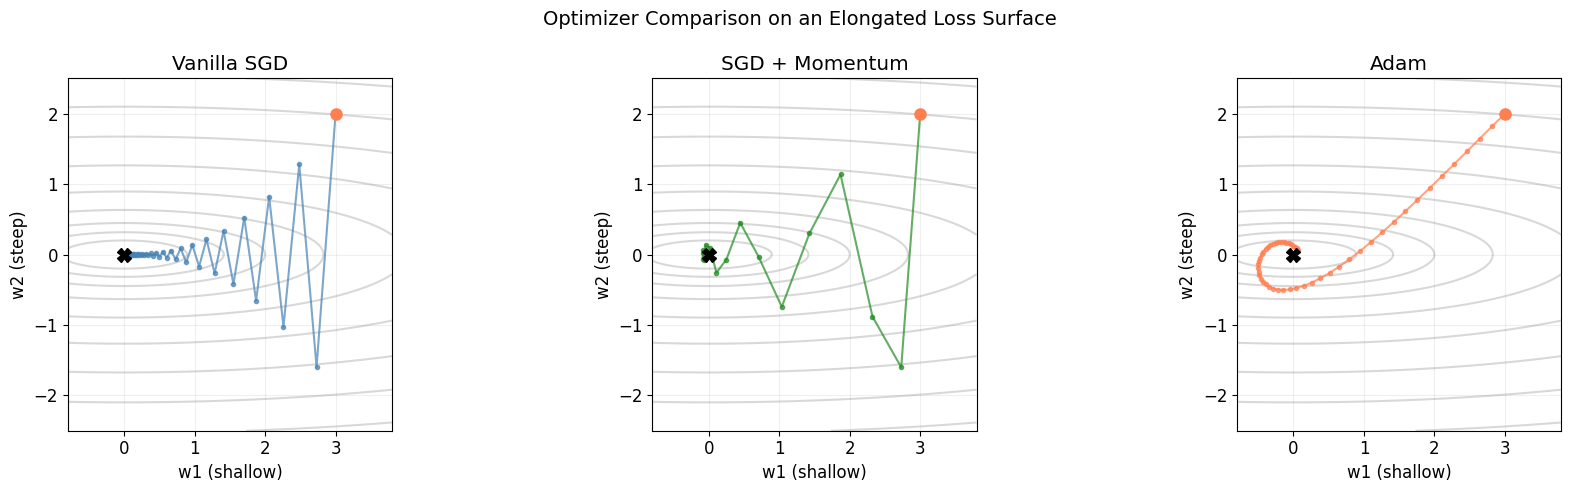

In [55]:
# Visualize all three optimizer paths
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create contour grid
w1_range = np.linspace(-0.8, 3.8, 200)
w2_range = np.linspace(-2.5, 2.5, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = 0.5 * (a_coeff * W1**2 + b_coeff * W2**2)
levels = [0.2, 0.5, 1, 2, 4, 8, 14, 22, 32]

paths = [sgd_path, mom_path, adam_path]
titles = ['Vanilla SGD', 'SGD + Momentum', 'Adam']
colors = ['steelblue', 'forestgreen', 'coral']

for ax, path, title, color in zip(axes, paths, titles, colors):
    ax.contour(W1, W2, L, levels=levels, colors='gray', alpha=0.3)
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], '-o', color=color, markersize=3,
            linewidth=1.5, alpha=0.7)
    ax.plot(path[0, 0], path[0, 1], 'o', color='coral', markersize=8, zorder=5)
    ax.plot(0, 0, 'X', color='black', markersize=10, zorder=5)
    ax.set_xlabel('w1 (shallow)')
    ax.set_ylabel('w2 (steep)')
    ax.set_title(title)
    ax.set_xlim(-0.8, 3.8)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Optimizer Comparison on an Elongated Loss Surface', fontsize=14)
plt.tight_layout()
plt.show()

**What to notice:**
- **Vanilla SGD** zigzags across the narrow valley. The gradient in the steep direction (w2) is much larger than in the shallow direction (w1), causing oscillation.
- **SGD + Momentum** dampens the zigzag. The alternating up/down gradients partially cancel in the velocity, while the consistent leftward gradients accumulate.
- **Adam** adapts the learning rate per parameter. w2 (which has large gradients) gets a smaller effective learning rate, reducing oscillation.

---
# Section 4: Training a Neural Network Regressor

We'll predict California housing prices using a neural network. This is the same dataset from Session 3 (linear regression), so you can compare how a neural network performs on a problem you've already solved with simpler models.


### Load and explore the data

In [31]:
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target

print(f'Features: {X_h.shape[1]} ({", ".join(housing.feature_names)})')
print(f'Samples: {X_h.shape[0]}')
print(f'Target: median house value (in $100,000s)')
print(f'Target range: {y_h.min():.2f} to {y_h.max():.2f}')

Features: 8 (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
Samples: 20640
Target: median house value (in $100,000s)
Target range: 0.15 to 5.00


### Preprocess: split and scale

In [32]:
# Train/test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# Scale features (always important for neural networks)
scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)  # transform, NOT fit_transform

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_h, dtype=torch.float32)
y_train_t = torch.tensor(y_train_h, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_h, dtype=torch.float32)
y_test_t = torch.tensor(y_test_h, dtype=torch.float32).reshape(-1, 1)

# Create DataLoaders for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f'Training set: {X_train_t.shape[0]} samples')
print(f'Test set:     {X_test_t.shape[0]} samples')
print(f'Batches per epoch: {len(train_loader)}')

Training set: 16512 samples
Test set:     4128 samples
Batches per epoch: 258


### Define the model

A simple MLP: 8 inputs → 64 hidden (ReLU) → 32 hidden (ReLU) → 1 output (no activation, since this is regression).

In [34]:
# Define model using nn.Sequential
model_reg = nn.Sequential(
    nn.Linear(8, 64),    # 8 input features -> 64 hidden neurons
    nn.ReLU(),
    nn.Linear(64, 32),   # 64 -> 32 hidden neurons
    nn.ReLU(),
    nn.Linear(32, 1)     # 32 -> 1 output (no activation for regression)
)

# Count parameters
n_params = sum(p.numel() for p in model_reg.parameters())
print(f'Model architecture:\n{model_reg}')
print(f'\nTotal parameters: {n_params:,}')

Model architecture:
Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 2,689


### The training loop

This is the five-step loop from the slides, with loss tracking for visualization.

In [35]:
# Training configuration
criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001)
n_epochs_reg = 50

# Track losses for plotting
train_losses_reg = []

for epoch in range(n_epochs_reg):
    model_reg.train()  # set to training mode
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # THE FIVE STEPS:
        optimizer_reg.zero_grad()              # 1. Reset gradients
        predictions = model_reg(X_batch)       # 2. Forward pass
        loss = criterion_reg(predictions, y_batch)  # 3. Compute loss
        loss.backward()                        # 4. Backward pass (backprop)
        optimizer_reg.step()                   # 5. Update weights

        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses_reg.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs_reg}, Train Loss: {avg_loss:.4f}')

Epoch 10/50, Train Loss: 0.3402
Epoch 20/50, Train Loss: 0.3000
Epoch 30/50, Train Loss: 0.2893
Epoch 40/50, Train Loss: 0.2761
Epoch 50/50, Train Loss: 0.2672


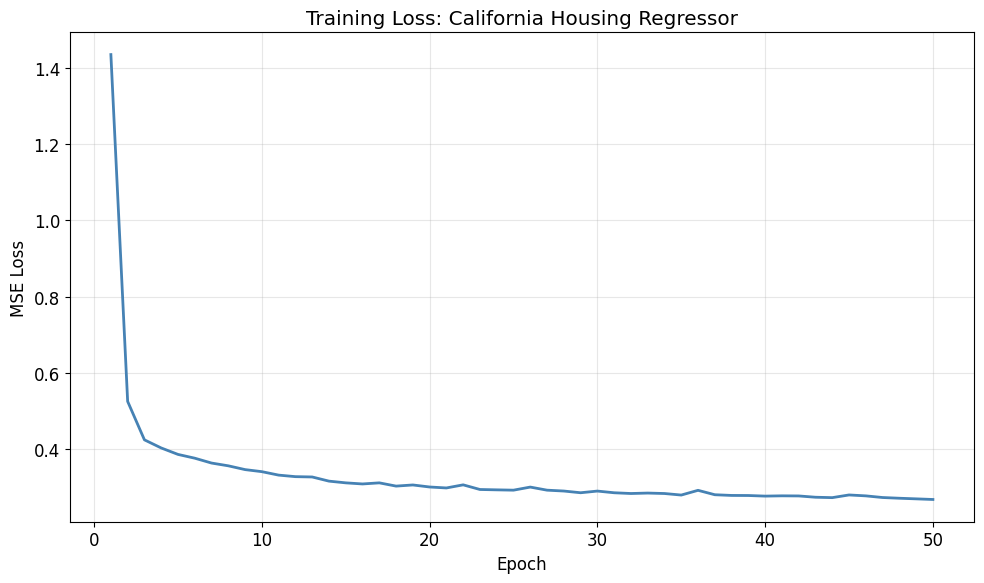

In [36]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, n_epochs_reg + 1), train_losses_reg, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss: California Housing Regressor')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluate on the test set

In [ ]:
model_reg.eval()  # set to evaluation mode
with torch.no_grad():  # no need to track gradients for evaluation
    y_pred_reg = model_reg(X_test_t).numpy()

rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_reg))
r2 = r2_score(y_test_h, y_pred_reg)
print(f'Test RMSE: {rmse:.4f} (in $100,000s)')
print(f'Test R-squared: {r2:.4f}')
print(f'\nFor comparison, a well-tuned linear regression gets R-squared ~ 0.60')

In [ ]:
# Predicted vs actual scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_h, y_pred_reg, alpha=0.3, s=10, color='steelblue')
ax.plot([0, 5.5], [0, 5.5], 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Price ($100,000s)')
ax.set_ylabel('Predicted Price ($100,000s)')
ax.set_title('Neural Network Regressor: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Exercise 2: Architecture Experiments (Regressor)

### Task 1: Wider network

Create a new model with wider hidden layers (128 and 64 neurons instead of 64 and 32). Train it for 50 epochs and compare the test RMSE to the original model.

In [ ]:
# Define a wider model: 8 -> 128 -> 64 -> 1
# Train it using the same training loop pattern as above
# Compare test RMSE

# Your code here

In [ ]:
#@title Click to reveal solution

model_wide = nn.Sequential(
    nn.Linear(8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion_wide = nn.MSELoss()
optimizer_wide = optim.Adam(model_wide.parameters(), lr=0.001)

for epoch in range(50):
    model_wide.train()
    for X_batch, y_batch in train_loader:
        optimizer_wide.zero_grad()
        predictions = model_wide(X_batch)
        loss = criterion_wide(predictions, y_batch)
        loss.backward()
        optimizer_wide.step()

model_wide.eval()
with torch.no_grad():
    y_pred_wide = model_wide(X_test_t).numpy()

rmse_wide = np.sqrt(mean_squared_error(y_test_h, y_pred_wide))
n_params_wide = sum(p.numel() for p in model_wide.parameters())
print(f'Original model: RMSE = {rmse:.4f}, params = {n_params:,}')
print(f'Wider model:    RMSE = {rmse_wide:.4f}, params = {n_params_wide:,}')

### Task 2: Deeper network

Create a model with three hidden layers (64, 32, 16). Does adding depth help?

In [ ]:
# Define a deeper model: 8 -> 64 -> 32 -> 16 -> 1
# Train and compare

# Your code here

In [ ]:
#@title Click to reveal solution

model_deep = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion_deep = nn.MSELoss()
optimizer_deep = optim.Adam(model_deep.parameters(), lr=0.001)

for epoch in range(50):
    model_deep.train()
    for X_batch, y_batch in train_loader:
        optimizer_deep.zero_grad()
        predictions = model_deep(X_batch)
        loss = criterion_deep(predictions, y_batch)
        loss.backward()
        optimizer_deep.step()

model_deep.eval()
with torch.no_grad():
    y_pred_deep = model_deep(X_test_t).numpy()

rmse_deep = np.sqrt(mean_squared_error(y_test_h, y_pred_deep))
n_params_deep = sum(p.numel() for p in model_deep.parameters())
print(f'Original (2 hidden): RMSE = {rmse:.4f}, params = {n_params:,}')
print(f'Wider (2 hidden):    RMSE = {rmse_wide:.4f}, params = {n_params_wide:,}')
print(f'Deeper (3 hidden):   RMSE = {rmse_deep:.4f}, params = {n_params_deep:,}')
print(f'\nMore parameters does not always mean better performance!')

---
# Section 5: Training a Neural Network Classifier

We'll classify tumors as malignant or benign using the Breast Cancer Wisconsin dataset. This is a binary classification task you have already solved with logistic regression and decision trees.


### Load and explore the data

In [ ]:
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

print(f'Features: {X_c.shape[1]}')
print(f'Samples: {X_c.shape[0]}')
print(f'Classes: {cancer.target_names}')
print(f'Class distribution:')
print(f'  0 (malignant): {(y_c == 0).sum()}')
print(f'  1 (benign):    {(y_c == 1).sum()}')

### Preprocess: split, scale, and convert to tensors

In [ ]:
# Train/test split (stratified to preserve class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Scale features
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)  # transform, NOT fit_transform

# Convert to PyTorch tensors
X_train_ct = torch.tensor(X_train_c, dtype=torch.float32)
y_train_ct = torch.tensor(y_train_c, dtype=torch.long)  # long for CrossEntropyLoss
X_test_ct = torch.tensor(X_test_c, dtype=torch.float32)
y_test_ct = torch.tensor(y_test_c, dtype=torch.long)

# DataLoader
train_dataset_c = TensorDataset(X_train_ct, y_train_ct)
train_loader_c = DataLoader(train_dataset_c, batch_size=32, shuffle=True)

print(f'Training set: {X_train_ct.shape[0]} samples')
print(f'Test set:     {X_test_ct.shape[0]} samples')

### Define the model

Binary classification, but we'll use 2 output neurons with softmax (via `CrossEntropyLoss`) rather than 1 output with sigmoid. This is the more general pattern that extends to multi-class.

In [ ]:
model_cls = nn.Sequential(
    nn.Linear(30, 32),     # 30 input features -> 32 hidden
    nn.ReLU(),
    nn.Linear(32, 16),     # 32 -> 16 hidden
    nn.ReLU(),
    nn.Linear(16, 2)       # 16 -> 2 outputs (one per class)
    # No softmax here! CrossEntropyLoss applies it internally.
)

n_params_c = sum(p.numel() for p in model_cls.parameters())
print(f'Model architecture:\n{model_cls}')
print(f'\nTotal parameters: {n_params_c:,}')

---
## Exercise 3: Write the Training Loop

You've seen the training loop in Section 4. Now write it yourself for the classifier.

### Task 1: Complete the training loop

Fill in the five key steps inside the inner loop. Track both training loss and training accuracy per epoch.

In [ ]:
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(model_cls.parameters(), lr=0.001)
n_epochs_cls = 60

train_losses_cls = []
train_accs_cls = []

for epoch in range(n_epochs_cls):
    model_cls.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader_c:
        # STEP 1: Reset gradients
        # Your code here

        # STEP 2: Forward pass
        # Your code here (store result in variable called 'logits')

        # STEP 3: Compute loss
        # Your code here (store result in variable called 'loss')

        # STEP 4: Backward pass
        # Your code here

        # STEP 5: Update weights
        # Your code here

        # Track metrics (don't change this part)
        epoch_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    train_losses_cls.append(avg_loss)
    train_accs_cls.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs_cls}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

In [ ]:
#@title Click to reveal solution

# Re-initialize model so the solution starts fresh
model_cls = nn.Sequential(
    nn.Linear(30, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(model_cls.parameters(), lr=0.001)
n_epochs_cls = 60

train_losses_cls = []
train_accs_cls = []

for epoch in range(n_epochs_cls):
    model_cls.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader_c:
        optimizer_cls.zero_grad()              # 1. Reset gradients
        logits = model_cls(X_batch)            # 2. Forward pass
        loss = criterion_cls(logits, y_batch)  # 3. Compute loss
        loss.backward()                        # 4. Backward pass
        optimizer_cls.step()                   # 5. Update weights

        epoch_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    train_losses_cls.append(avg_loss)
    train_accs_cls.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs_cls}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

### Task 2: Plot the training curves

Plot training loss and training accuracy side by side.

In [ ]:
# Create a 1x2 figure with loss on the left and accuracy on the right

# Your code here

In [ ]:
#@title Click to reveal solution

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, n_epochs_cls + 1), train_losses_cls, color='steelblue', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, n_epochs_cls + 1), train_accs_cls, color='forestgreen', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim(0.8, 1.01)
ax2.grid(True, alpha=0.3)

plt.suptitle('Breast Cancer Classifier: Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate on the test set

In [ ]:
model_cls.eval()
with torch.no_grad():
    logits_test = model_cls(X_test_ct)
    _, y_pred_cls = torch.max(logits_test, 1)
    y_pred_cls = y_pred_cls.numpy()

print(f'Test Accuracy: {accuracy_score(y_test_c, y_pred_cls):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test_c, y_pred_cls,
                            target_names=['malignant', 'benign']))

---
## Exercise 4: Optimizer Showdown

### Task 1: Compare optimizers on the classifier

Train three versions of the classifier (same architecture) using:
1. `optim.SGD(lr=0.01)` — vanilla SGD
2. `optim.SGD(lr=0.01, momentum=0.9)` — SGD with momentum
3. `optim.Adam(lr=0.001)` — Adam

Track the training loss for each and plot all three loss curves on the same figure.

Hint: write a helper function that takes a model and optimizer, runs the training loop, and returns the list of losses.

In [ ]:
# Hint: a reusable training function
#
# def train_model(model, optimizer, train_loader, criterion, n_epochs):
#     losses = []
#     for epoch in range(n_epochs):
#         model.train()
#         epoch_loss = 0.0
#         ... (the 5-step loop) ...
#         losses.append(avg_loss)
#     return losses
#
# Then create 3 fresh models and 3 optimizers, train each, plot the losses

# Your code here

In [ ]:
#@title Click to reveal solution

def train_model(model, optimizer, train_loader, criterion, n_epochs):
    losses = []
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        total = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)
        losses.append(epoch_loss / total)
    return losses

def make_model():
    torch.manual_seed(42)  # same initialization for fair comparison
    return nn.Sequential(
        nn.Linear(30, 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 2)
    )

criterion = nn.CrossEntropyLoss()
n_ep = 60

# Train with each optimizer
model_sgd = make_model()
losses_sgd = train_model(model_sgd, optim.SGD(model_sgd.parameters(), lr=0.01),
                         train_loader_c, criterion, n_ep)

model_mom = make_model()
losses_mom = train_model(model_mom, optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9),
                         train_loader_c, criterion, n_ep)

model_adam = make_model()
losses_adam = train_model(model_adam, optim.Adam(model_adam.parameters(), lr=0.001),
                          train_loader_c, criterion, n_ep)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, n_ep+1), losses_sgd, color='steelblue', linewidth=2, label='SGD (lr=0.01)')
ax.plot(range(1, n_ep+1), losses_mom, color='forestgreen', linewidth=2, label='SGD + Momentum')
ax.plot(range(1, n_ep+1), losses_adam, color='coral', linewidth=2, label='Adam (lr=0.001)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Optimizer Comparison: Breast Cancer Classifier')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final accuracies
for name, model in [('SGD', model_sgd), ('Momentum', model_mom), ('Adam', model_adam)]:
    model.eval()
    with torch.no_grad():
        _, preds = torch.max(model(X_test_ct), 1)
    print(f'{name:10s} test accuracy: {accuracy_score(y_test_c, preds.numpy()):.4f}')

---
# Summary

**Key takeaways from this notebook:**

- **Autograd** computes backpropagation automatically. Call `loss.backward()` and PyTorch traces the computational graph in reverse to compute every gradient.
- **Gradients accumulate** by default — that's why `optimizer.zero_grad()` is the first step in every training iteration.
- **The training loop is five lines:** zero gradients → forward pass → compute loss → backward pass → optimizer step. This pattern is the same regardless of model complexity.
- **Loss curves** are your primary diagnostic tool. Training loss should decrease; divergence means the learning rate is too high; a plateau may mean it's too low or the model has converged.
- **Optimizer choice matters.** Adam is the default starting point; SGD with momentum can work well with careful tuning.
- **More parameters ≠ better performance.** Wider and deeper models have more capacity, but that capacity can overfit.
